## OBJETIVO 3: Analizar la exigencia y los aspectos relevantes según la nacionalidad de cada usuario (definir pocas nacionalidades)

## 0. Librerías y cargar datos

In [93]:
# Librerías
import pandas as pd
import numpy as np
# NLP clásico
import spacy
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
# Topic modeling
from sentence_transformers import SentenceTransformer # embeddings
from bertopic import BERTopic # topic modeling
from umap import UMAP # reducción de dimensionalidad
from hdbscan import HDBSCAN # clusterización
# Visualización
import seaborn as sns
import matplotlib.pyplot as plt
# Análisis de especifidad
from scipy.stats import chi2_contingency

Para esta fase del proyecto identificamos y filtramos el dataset del conjunto completo de reseñas para quedarnos únicamente con las diez nacionalidades que acumulan el mayor volumen de reseñas, garantizando así la solidez estadística del estudio. Hemos desarrollado un algoritmo de limpieza que aplicamos de forma independiente a los comentarios positivos y negativos. Con esta función eliminamos respuestas evasivas tipo "nada" y lematizamos cada palabra para reducirla a su raíz semántica, obteniendo así un corpus completamente normalizado y listo para la extracción de conclusiones.

In [7]:
# Cargamos los datos completos
df_base = pd.read_csv('datos/procesados/df_comentarios_traducidos.csv')

# Detectamos automáticamente las 10 nacionalidades con más reseñas
nacionales_top = df_base['nacionalidad'].value_counts().head(10).index.tolist()
print(f"Nacionalidades principales detectadas para el estudio: {nacionales_top}")

# Creamos el DataFrame de trabajo filtrado
df_proyecto = df_base[df_base['nacionalidad'].isin(nacionales_top)].copy()

# Cargar spaCy en español
nlp = spacy.load('es_core_news_sm')
stopwords_es = list(nlp.Defaults.stop_words)

# Rescatamos palabras clave que indican queja o cuantificación
relevantes = ['mejor', 'buenas', 'no', 'más', 'buenos', 'pocos', 'apenas', 'tampoco', 'buena', 'bastante']
for palabra in relevantes:
    if palabra in stopwords_es:
        stopwords_es.remove(palabra)

# Añadimos palabras obvias que sesgan el análisis de hoteles
stopwords_es.extend(["hotel", "valencia", "habitacion", "habitación", "alojamiento", "estancia", "establecimiento"])

def limpiar_y_lematizar(texto):
    """Transforma el texto a minúsculas, elimina stopwords y extrae la raíz (lema)"""
    if pd.isna(texto) or str(texto).strip() == "" or str(texto).lower() == "ninguna" or str(texto).lower() == "nada":
        return ""
    
    doc = nlp(str(texto).lower())
    # Filtramos por longitud y stopwords, extrayendo el lema
    tokens_limpios = [token.lemma_ for token in doc if token.text not in stopwords_es and len(token.text) >= 3]
    return ' '.join(tokens_limpios)

print("Limpiando textos de reseñas... Esto puede tardar un par de minutos.")
# Aplicamos la limpieza de forma independiente a la columna de positivos y de negativos
df_proyecto['positivo_clean'] = df_proyecto['positivo'].apply(limpiar_y_lematizar)
df_proyecto['negativo_clean'] = df_proyecto['negativo'].apply(limpiar_y_lematizar)
print("¡Textos listos y normalizados!")

# Guardamos los textos procesados, posteriormente podemos cargar este dataframe en lugar de volver a lematizar
df_proyecto.to_csv("datos/procesados/df_lemas_10_nacionalidades.csv", index=False, encoding='utf-8-sig')

# Mostramos cómo ha quedado el dataframe
display(df_proyecto.head())

Nacionalidades principales detectadas para el estudio: ['españa', 'italia', 'reino unido', 'países bajos', 'alemania', 'francia', 'suiza', 'bélgica', 'argentina', 'estados unidos']
Limpiando textos de reseñas... Esto puede tardar un par de minutos.
¡Textos listos y normalizados!


,nombre_del_hotel,nacionalidad,detalles_hab,noches,personas,comentario_general,positivo,negativo,nota,fecha,comentario_media_hotel,positivo_clean,negativo_clean
1,barceló valencia,españa,NaN,1,pareja,muy bien,NaN,NaN,9.0,2026-04-05,fabuloso,,
2,barceló valencia,españa,2 habitaciones dobles deluxe comunicadas,1,familia,fantástico,"habitaciones amplias, limpieza y ubicación",NaN,9.0,2026-04-03,fabuloso,habitación amplio limpieza ubicación,
3,barceló valencia,españa,NaN,1,pareja,todo perfecto,el trato en recepción,el estacionamiento,10.0,2026-03-21,fabuloso,trato recepción,estacionamiento
4,barceló valencia,españa,NaN,2,pareja,una nit del foc inolvidable.,las vistas y el tamaño de la habitación.,"la calefacción central, sólo eso.",10.0,2026-03-20,fabuloso,vista tamaño,calefacción central
5,barceló valencia,españa,NaN,1,pareja,excepcional,me encantó,todo súper bien,10.0,2026-03-17,fabuloso,encantar,súper


## 1. Primera prueba: una única nacionalidad
Para realizar las primeras pruebas sobre el proceso de extracción de topics y análisis por nacionalidad nos centraremos en un subconjunto más pequeño de los datos restringiéndolos a una nacionalidad concreta. 
Hemos escogido realizar esta prueba con los comentarios de clientes procedentes de bélgica, ha resultado interesante realizar esta prueba para un país no hispanohablante para verificar si el reducido número de reseñas que quedaron sin traducir (la traducción automática no funcionó correctamente) suponen un problema o si utilizar un modelo multilingue permite procesar sin problemas estos datos en el conjunto.

In [73]:
# De momento probamos con una nacionalidad, polonia
df = df_proyecto[df_proyecto['nacionalidad']=='bélgica']

display(df.head())

,nombre_del_hotel,nacionalidad,detalles_hab,noches,personas,comentario_general,positivo,negativo,nota,fecha,comentario_media_hotel,positivo_clean,negativo_clean
431,barceló valencia,bélgica,NaN,1,persona que viaja sola,hotel superior,desayuno y bar en la azotea,la condición física podría ser mejor,9.0,2025-06-02,fabuloso,desayuno bar azotea,condición físico mejor
456,barceló valencia,bélgica,NaN,4,pareja,estancia perfecta! ¡Esperando con ansias mi pr...,hermoso hotel; Mejor ubicación entre el centro...,NaN,9.0,2025-01-02,fabuloso,hermoso mejor ubicación centro histórico playa...,
584,barceló valencia,bélgica,NaN,1,pareja,Un lugar genial para alojarse en Valencia.,"excelente personal, excelente ubicación, marav...",NaN,9.0,2023-06-05,fabuloso,excelente personal excelente ubicación maravil...,
586,barceló valencia,bélgica,NaN,4,grupo,"gran servicio, excelente ubicación, excelente ...","Super desayuno, personal servicial y muy acoge...",no hay nada que no me haya gustado. fue perfecto,10.0,2023-05-30,fabuloso,super desayuno personal servicial acogedor her...,gustar perfecto
643,barceló valencia,bélgica,NaN,3,persona que viaja sola,el hotel estaba bien,desayuno perfecta ubicación ok,El café y el agua en la habitación solo a la l...,9.0,2023-05-16,fabuloso,desayuno perfecto ubicación,café agua llegada volver llenar café


### 1.1 Extracción de embeddings y topic modeling
En primer lugar extraeremos los embeddings de cada reseña, utilizando un SentenceTransformer para que se tenga en cuenta el contexto de oraciones completas, en lugar de solamente cada palabra por separado.  
Estos embeddings se extraen con el texto "en sucio" de nuestro dataset: traducido, sin emojis y en minúsculas, pero sin lematización ni eliminación de stopwords.  
Posteriormente utilizaremos BERTopic para extraer los temas, la clusterización se realizará con los embeddings calculados pero para posteriormente asignar sentido a cada tema con TF-IDF haremos una limpieza previa de las stopwords definidas anteriormente.

In [13]:
# Para topic modeling nos quedaremos con los comentarios sin lematizar, generalmente mejores para modelos transformer
# Extraer positivos y negativos con su etiqueta
pos = df[['positivo']].dropna().rename(columns={'positivo': 'text'})
pos['sentiment'] = 'Positivo'

neg = df[['negativo']].dropna().rename(columns={'negativo': 'text'})
neg['sentiment'] = 'Negativo'

# Combinar ambos en un solo corpus
df_mixed = pd.concat([pos, neg], ignore_index=True)
documents = df_mixed['text'].astype(str).tolist()

print(f"Total de documentos (Pos + Neg) bélgica: {len(pos)}+{len(neg)} = {len(documents)}")


# Extracción de embeddings
#embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")
embeddings = embedding_model.encode(documents, show_progress_bar=True)

# Reducción de dimensionalidad y Clustering
umap_model = UMAP(n_neighbors=15, n_components=3, min_dist=0.0, metric='cosine', random_state=42)

hdbscan_model = HDBSCAN(min_cluster_size=20, min_samples=10, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# Vectorizador
# Código para obtener las stopwords por si se tiene que volver a ejecutar

# # Cargar spaCy en español
# nlp = spacy.load('es_core_news_sm')
# stopwords_es = list(nlp.Defaults.stop_words)
# # Rescatamos palabras clave que indican queja o cuantificación
# relevantes = ['mejor', 'buenas', 'no', 'más', 'buenos', 'pocos', 'apenas', 'tampoco', 'buena', 'bastante']
# for palabra in relevantes:
#     if palabra in stopwords_es:
#         stopwords_es.remove(palabra)
# # Añadimos palabras obvias que sesgan el análisis de hoteles
# stopwords_es.extend(["hotel", "valencia", "habitacion", "habitación", "alojamiento", "estancia", "establecimiento"])

#Configuramos el vectorizador
# El token_pattern r"(?u)\b[a-zA-ZáéíóúÁÉÍÓÚñÑ]{2,}\b" obliga a que los tokens:
# - Tengan al menos 2 caracteres.
# - Solo contengan letras (incluyendo tildes y ñ), eliminando así los números.
vectorizer_model = CountVectorizer(
    stop_words=stopwords_es, #ademas de quitar las stopwords
    token_pattern=r"(?u)\b[a-zA-ZáéíóúÁÉÍÓÚñÑ]{2,}\b"
)

# Al crear el modelo, le pasamos este vectorizador
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="multilingual"
)

# Aquí puedes usar los documents originales sin problemas
topics, probs = topic_model.fit_transform(documents, embeddings)
df_mixed["topic"] = topics

Total de documentos (Pos + Neg) bélgica: 746+617 = 1363


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/43 [00:00<?, ?it/s]

A continuación analizaremos los temas obtenidos y las opiniones de los huéspedes respecto a cada uno de ellos en base a las reseñas positivas y negativas de cada uno de ellos.

In [14]:
# Ver la distribución de sentimiento por cada tema encontrado
df_distribucion = df_mixed.groupby(['topic', 'sentiment']).size().unstack(fill_value=0)
df_distribucion['Total'] = df_distribucion.sum(axis=1)
df_distribucion['% Positivo'] = (df_distribucion['Positivo'] / df_distribucion['Total'] * 100).round(2)

print("Distribución de sentimiento por Topic (¿Hubo separación?):")
display(df_distribucion)

# Mostrar palabras clave de los temas con más "Negativos" y más "Positivos"
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))

Distribución de sentimiento por Topic (¿Hubo separación?):


sentiment,Negativo,Positivo,Total,% Positivo
topic,,,,
0,448,633,1081,58.56
1,32,25,57,43.86
2,44,1,45,2.22
3,41,3,44,6.82
4,1,40,41,97.56
5,21,18,39,46.15
6,4,25,29,86.21
7,26,1,27,3.70


,Topic,Count,Name,Representation,Representative_Docs
0,0,1081,0_no_desayuno_ubicación_personal,"[no, desayuno, ubicación, personal, amable, ex...","[ubicación y buen desayuno, el desayuno no es ..."
1,1,57,1_situación_pulgar_instalaciones_falta,"[situación, pulgar, instalaciones, falta, azot...","[la situación, Las actividades podrían ser mej..."
2,2,45,2_no___,"[no, , , , , , , , , ]","[No., No, no]"
3,3,44,3_comentarios_quejarse_negativo_especial,"[comentarios, quejarse, negativo, especial, re...","[sin comentarios., sin comentarios, realmente ..."
4,4,41,4_ubicación_locatie_privilegiada_muceos,"[ubicación, locatie, privilegiada, muceos, úni...","[la ubicación, ubicación, la ubicación!]"
5,5,39,5_perfecto_agrado_gustó_esperaba,"[perfecto, agrado, gustó, esperaba, genial, gu...","[perfecto, todo fue perfecto, ¡fue perfecto!]"
6,6,29,6_personal_corazones_amable_recepción,"[personal, corazones, amable, recepción, amabi...","[personal amable, el personal de recepción fue..."
7,7,27,7_absolutamente___,"[absolutamente, , , , , , , , , ]","[Nada, ¡absolutamente nada!, absolutamente nada.]"


Analizamos también algunos ejemplos de reseñas para cada topic:

In [15]:
for topic in np.unique(topics):
    if topic == -1:
        continue

    print(f'======= TOPIC  {topic} =======')
    # Mostramos palabras clave
    words = topic_model.get_topic(topic)
    topic_words = [word for word, score in words[:5]]
    print('Palabras clave: ', ' '.join(topic_words))

    # Mostramos tres ejemplos de comentarios positivos y negativos (si hay)
    # Positivos
    if df_distribucion['Positivo'][topic] >= 3:
        print('\n Comentarios positivos')
        aux = df_mixed[df_mixed['sentiment']=='Positivo'][df_mixed['topic']==topic].sample(3)
        aux = aux['text'].tolist()
        print('\n'.join(aux))

    elif df_distribucion['Positivo'][topic] > 0:
        print('\n Comentarios positivos')
        aux = df_mixed[df_mixed['sentiment']=='Positivo'][df_mixed['topic']==topic]

    # Negativos 
    if df_distribucion['Negativo'][topic] >= 3:
        print('\n Comentarios negativos')
        aux = df_mixed[df_mixed['sentiment']=='Negativo'][df_mixed['topic']==topic].sample(3)
        aux = aux['text'].tolist()
        print('\n'.join(aux))

    elif df_distribucion['Negativo'][topic] > 0:
        print('\n Comentarios negativos')
        aux = df_mixed[df_mixed['sentiment']=='Negativo'][df_mixed['topic']==topic]
        aux = aux['text'].tolist()
        print('\n'.join(aux))


======= TOPIC  0 =======
Palabras clave:  no desayuno ubicación personal amable

 Comentarios positivos
habitación espaciosa. Paradas de autobús en el hotel. Bar en la azotea con vistas.
Desayuno fabuloso, con mucha variedad y calidad.
ubicación perfecta, buen desayuno

 Comentarios negativos
El aire acondicionado consta de ventiladores, lo que mantiene demasiado caliente las habitaciones. Además, en toda la planta sólo hay 3 duchas y 4 aseos. El ruido de la calle puede ser molesto, pero personalmente no me molestó mucho. un mal colchón
La presión de la ducha era muy baja.
la sucesión de bolsas y platos... nunca o rara vez había bolsas debajo. En el rincón del café rara vez había suficientes bolsas.
======= TOPIC  1 =======
Palabras clave:  situación pulgar instalaciones falta azotea

 Comentarios positivos
¡ubicación!
lugar
la sercania al rioturia

 Comentarios negativos
la recepccionista
La zona del espacio es lo que se raya.
 
======= TOPIC  2 =======
Palabras clave:  no    

 Comen

Los resultados para este método parecen ser difíciles de interpretar y no dan lugar a conclusiones claras.

### 1.2. Análisis clásico
Ya que el topic modeling probado no ha llevado a resultados muy concluyentes a continuación realizaremos un análisis clásico de las reseñas basado en frecuencias de palabras, concretamente utilizaremos las técnicas TF-IDF y Log Odds Ratio. Para este tipo de aplicaciones sí que es conveniente utilizar el texto limpio, sin stopwords y con lematización.

#### 1.2.1 TF-IDF
Utilizaremos TF-IDF para extraer los términos más relevantes para cada nacionalidad, con el objetivo de posteriormente realizar un estudio comparativo entre ellos (DELTA TF-IDF). 

In [76]:
# Obtenemos los documentos a partir de las reseñas limpias
# Extraer positivos y negativos con su etiqueta
pos = df[['positivo_clean']].dropna().rename(columns={'positivo_clean': 'text'})
pos['sentiment'] = 'Positivo'
# Eliminar celdas vacías
pos = pos[pos['text'] != ""]

neg = df[['negativo_clean']].dropna().rename(columns={'negativo_clean': 'text'})
neg['sentiment'] = 'Negativo'
# Eliminar celdas vacías
neg = neg[neg['text'] != ""]

# Combinar ambos en un solo corpus
df_mixed = pd.concat([pos, neg], axis=0, ignore_index=True)
lemma_docs = df_mixed['text'].astype(str).tolist()

In [78]:
# Apicamos TF-IDF y obtenemos palabras de mayor peso
tv = TfidfVectorizer(ngram_range=(2,2), min_df=0.003, max_df=0.6, norm=None) # Palabras únicas son difíciles de interpretar, nos centramos en bigramas y trigramas
# Hacemos fit de tv a los comentarios tanto positivos como negativos
tv_sparse_matrix = tv.fit_transform(lemma_docs)

tv_matrix = tv_sparse_matrix.toarray()
vocab_bigram = tv.get_feature_names_out()

# Obtenemos los 40 elementos de mayor peso (más adelante evaluaremos cuántos conviene utilizar para comparar)
idx_top = np.argsort(tv_matrix.max(axis=0))[-40:]
palabras_top = vocab_bigram[idx_top]
print(palabras_top)

['desayuno caro' 'desayuno limpio' 'desayuno perfecto' 'desayuno pequeño'
 'espera ascensor' 'extremadamente amable' 'escuchar ruido'
 'escobilla baño' 'dormir noche' 'haber reservar' 'limpio moderno'
 'parada autobús' 'ubicación vista' 'tener cambiar' 'servicio limpieza'
 'buen ducha' 'ascensor lento' 'amplio baño' 'aparcamiento público'
 'cara sonreir' 'decir él' 'delicioso desayuno' 'plaza ayuntamiento'
 'personal excelente' 'personal extremadamente' 'piscina abierto'
 'personal super' 'punto negativo' 'ubicación realmente' 'valer pena'
 'vista mar' 'super bonito' 'ruido pasillo' 'ubicación mejor'
 'ubicación amabilidad' 'ubicación increíble' 'aire acondicionado'
 'habitación pequeño' 'bonito bar' 'tener esperar']


A continuación trataremos de estimar cómo se sienten los clientes acerca de cada uno de los términos de gran importancia nombrados evaluando la proporción de apariciones que tienen estas palabras en reseñas positivas vs negativas.

In [79]:
# Obtener proporción de cada término en reseñas positivas/negativas
# Utilizamos un dataframe auxiliar para reco
df_tv = pd.DataFrame(np.round(tv_matrix, 2), columns=vocab_bigram)

# Creamos variable de dataframe para la proporción de cada término
df_prop_tv = None

# Recorremos cada término
for ngrama in palabras_top:
    # Encontrar el índice de los documentos en los que su score no es 0, usarlo en df_mixed para hallar el tipo de reseña
    sentimientos = df_mixed['sentiment'][df_tv[ngrama]!=0.0].to_numpy()
    # Proporción positivos
    prop_pos = np.sum(sentimientos=='Positivo')/len(sentimientos)
    # Proporción negativos
    prop_neg = np.sum(sentimientos=='Negativo')/len(sentimientos)
    # Si el dataframe no existe lo creamos, si ya existe se inserta una nueva fila
    if isinstance(df_prop_tv, pd.DataFrame): 
        df_prop_tv.loc[len(df_prop_tv)] = [ngrama, prop_pos, prop_neg]
    else:
        df_prop_tv = {'Término': [ngrama], 'Proporcion positivo': [prop_pos], 'Proporcion negativo': [prop_neg]}
        df_prop_tv = pd.DataFrame(df_prop_tv)
    
# Vemos cómo quedaría en los 10 primeros casos
display(df_prop_tv.head(20))

,Término,Proporcion positivo,Proporcion negativo
0,desayuno caro,0.25,0.75
1,desayuno limpio,1.00,0.00
2,desayuno perfecto,1.00,0.00
3,desayuno pequeño,0.50,0.50
4,espera ascensor,0.00,1.00
5,extremadamente amable,1.00,0.00
6,escuchar ruido,0.25,0.75
7,escobilla baño,0.00,1.00
8,dormir noche,0.25,0.75
9,haber reservar,0.75,0.25


#### 1.2.2 Log Odds Ratio with Informative Dirichlet Prior
A la hora de analizar frecuencias de palabras en documentos, una alternativa a los métodos TF-IDF o Bag of Words es el Log Odds Ratio, esta métrica tratará de evaluar la probabilidad de encontrar una palabra o n-grama en una determinada categoría (en nuestro caso, una nacionalidad) respecto a la probabilidad de que esta palabra se encuentre en otra categoría.   
Dado que este es un método directamente comparativo no podemos hacer esta primera prueba solamente con los datos de una nacionalidad, por lo que escogeremos una segunda nacionalidad con la que comparar (más adelante ya se realizará para todas las nacionalidades).  

In [96]:
# Compararemos con, por ejemplo, las reseñas de Italia
df2 = df_proyecto[df_proyecto['nacionalidad'] == 'italia']

# Extraer positivos y negativos con su etiqueta
pos2 = df2[['positivo_clean']].dropna().rename(columns={'positivo_clean': 'text'})
pos2['sentiment'] = 'Positivo'
# Eliminar celdas vacías
pos2 = pos2[pos2['text'] != ""]

neg2 = df2[['negativo_clean']].dropna().rename(columns={'negativo_clean': 'text'})
neg2['sentiment'] = 'Negativo'
# Eliminar celdas vacías
neg2 = neg2[neg2['text'] != ""]

# Obtenemos un dataframe combinado para consultas posteriores
df_mixed_it = pd.concat([pos2, neg2], ignore_index=True)

print(f"Total de documentos (Pos + Neg) italia: {len(pos2)}+{len(neg2)} = {len(df_mixed_it)}")

Total de documentos (Pos + Neg) italia: 4852+2847 = 7699


Para calcular el z-score de log odds partimos de las cuentas de cada palabra en cada documento, y en total, para realizar esta parte de manera rápida y automática utilizaremos Bag of Words de spacy. Como lo que queremos saber es la frecuencia de las palabras para cada nacionalidad necesitaremos tener un corpus completo común, uniremos los dos corpus normalizados que tenemos creando también una nueva variable (etiquetas) que permita consultar posteriormente a qué nacionalidad pertenece cada documento. Definimos a continuación una función para realizar este proceso.

In [ ]:
def contar_palabras_nacionalidad(docs, etiquetas, ngram_range=(1,2)):
    # Bag of words del corpus completo
    cv = CountVectorizer(ngram_range=ngram_range, min_df=0.003, max_df=0.6)
    cv_matrix_sparse = cv.fit_transform(docs)
    cv_matrix = cv_matrix_sparse.toarray()
    # Vocabulario
    vocab = cv.get_feature_names_out()
    # Guardamos las cuentas en un dataframe para tener referencia de a qué término pertenece cada uno
    df_bow = pd.DataFrame(cv_matrix, columns=vocab)

    # Ahora creamos otro dataframe que permita obtener las cuentas de cada término por nacionalidad (agrupando)
    # Tendremos que iterar por las etiquetas
    cuentas_nac = []
    for etiqueta in np.unique(etiquetas):
        cuentas_nac.append(df_bow.loc[np.array(etiquetas)==etiqueta,:].sum(axis=0))
    
    # dataframe completo
    df_counts = pd.concat(cuentas_nac, axis=1).transpose()
    # crear diccionario para renombrar indices
    rename_idx = {i: nacionalidad for i, nacionalidad in enumerate(np.unique(etiquetas))}
    df_counts = df_counts.rename(index=rename_idx)

    return df_counts

Una vez tenemos las apariciones de cada n-grama divididas por nacionalidad trataremos de implementar el cálculo del score correspondiente a Log Odds Ratio. Este score se calcularía así:  
$$ \log{\frac{p_1}{(1-p_1)}}=\log{\frac{p_1}{p_2}} = \log{p_1} - \log{p_2} $$

donde $p_1$ es la probabilidad de que un cierto n-grama aparezca en el corpus 1 y $p_2$ la probabilidad de que aparezca en el corpus 2. Si se trabaja con cuentas de cada palabra, $c_1$ para las apariciones en el corpus 1 y $c_2$ para sus apariciones en el corpus 2 (donde $\Sigma c_1$ y $\Sigma c_2$ son el número total de n-gramas que aparecen en cada corpus) el término se reescribe como:

$$ \log{\frac{c_1}{\Sigma c_1}} - \log{\frac{c_2}{\Sigma c_2}} = \log{c_1} - \log{\Sigma c_1} - \log{c_2} + \log{\Sigma c_2} $$

Adicionalmente, con tal de evitar posibles errores cuando alguno de estos términos ($c_1$ o $c_2$) es 0 y suavizar la función se añade tanto a $c_1$ como a $c_2$ una pequeña cantidad determinada por un parámetro $\alpha$.

In [125]:
def LogOdds_2nac(df_counts, alpha=0.01): # Función adaptada a tener solamente 2 nacionalidades diferentes
    # Nacionalidades
    nac1, nac2 = df_counts.index.tolist()

    # Cuentas totales
    c1_total = df_counts.loc[nac1,:].sum()
    c2_total = df_counts.loc[nac2,:].sum()
    # Dataframe para guardar los resultados
    logodds = pd.DataFrame(data=np.zeros((1, df_counts.shape[1])), columns=df_counts.columns, index=[0])

    # Iteramos sobre cada término
    for col in df_counts.columns.tolist():
        # Cuentas
        c1 = df_counts.loc[nac1, col]
        c2 = df_counts.loc[nac2, col]

        # Suavizado
        c1 += alpha
        c2 += alpha

        # Calcular score
        zscore = np.log(c1) - np.log(c1_total) - np.log(c2) + np.log(c2_total)

        # Guardar score en logodds
        logodds.loc[0,col] = zscore

    # Guardamos logodds ordenado
    logodds = logodds.sort_values(by=0, axis=1)

    return logodds

Para este estudio resulta interesante mantener la información de si los términos utilizados más por una nacionalidad u otra vienen referidos a quejas o comentarios positivos, por lo que realizaremos el cálculo de las puntuaciones de forma separada para los comentarios positivos y negativos.

**Comentarios positivos:**

In [136]:
# Corpus completo
pos_total = pd.concat([pos['text'], pos2['text']]).tolist()
# Etiquetas nacionalidad, de aquí sacaremos los índices para filtrar posteriormente
nac_docs_pos = np.array(['bélgica']*len(pos) + ['italia']*len(pos2))

# Contar apariciones de cada palabras
cuentas_pos = contar_palabras_nacionalidad(pos_total, nac_docs_pos)
display(cuentas_pos)
# Calcular logodds, términos muy negativos son más frecuentes para italia y positicos para bélgica
logodds_pos = LogOdds_2nac(cuentas_pos)
display(logodds_pos)

,abierto,absolutamente,abundante,abundante desayuno,abundante variado,accesible,acceso,acogedor,acogedor limpio,acogedor servicial,...,zona,zona común,zona tranquilo,área,él,él ciudad,él pie,óptimo,único,útil
bélgica,1,4,16,2,2,6,7,10,0,0,...,14,2,0,1,17,0,1,1,3,2
italia,22,33,198,43,27,40,26,217,19,24,...,193,30,22,26,184,30,22,30,39,41


,estructura,posición,dulce,estratégico,salado,italiano,dulce salado,comunicado,oceanográfico,excelente limpieza,...,genial,ubicación ideal,delicioso,azotea,ropa cama,buena,antiguo,casco,casco antiguo,buena cama
0,-8.425949,-7.975992,-7.40434,-7.336751,-7.161412,-6.979107,-6.873757,-6.816606,-6.691458,-6.691458,...,2.25602,2.331367,2.377865,2.489029,2.518738,2.661847,2.720678,2.818676,2.923926,4.367


In [140]:
# Sacamos los 10 términos más característicos de cada nacionalidad
top_10_it = logodds_pos.iloc[:,0:10].columns.tolist() # Los scores más negativos
top_10_bel = logodds_pos.iloc[:,-11:-1].columns.tolist() # Los scores más positivos

print(f'''Términos utilizados más característicos de cada nacionalidad en reseñas positivas: \n Bélgica: {" ".join(top_10_bel)} \n Italia: {" ".join(top_10_it)}''')

Términos utilizados más característicos de cada nacionalidad en reseñas positivas: 
 Bélgica: ubicación genial genial ubicación ideal delicioso azotea ropa cama buena antiguo casco casco antiguo 
 Italia: estructura posición dulce estratégico salado italiano dulce salado comunicado oceanográfico excelente limpieza


**Comentarios negativos:**

In [128]:
# Corpus completo
neg_total = pd.concat([neg['text'], neg2['text']]).tolist()
# Etiquetas nacionalidad, de aquí sacaremos los índices para filtrar posteriormente
nac_docs_neg = np.array(['bélgica']*len(neg) + ['italia']*len(neg2))

# Contar apariciones de cada palabras
cuentas_neg = contar_palabras_nacionalidad(neg_total, nac_docs_neg)
display(cuentas_neg)
# Calcular logodds, términos muy negativos son más frecuentes para italia y positicos para bélgica
logodds_neg = LogOdds_2nac(cuentas_neg)
display(logodds_neg)

,00,30,abajo,abierto,abrir,abrir ventana,absolutamente,absoluto,acceso,accesorio,...,wifi,yo,zona,zona común,área,él,él más,único,único defecto,útil
bélgica,3,5,1,12,10,4,3,4,3,0,...,7,6,11,0,3,43,2,10,0,2
italia,15,21,17,33,35,14,17,11,18,11,...,12,33,45,19,17,229,9,108,43,14


,bidé,interno,único defecto,bidet,italiano,insonorizado,nota,prácticamente,puerta baño,desayuno incluido,...,manta,extra,fresco,visto,inglés,aislamiento,duro,ruido exterior,estacionamiento,largo
0,-7.523216,-6.93551,-6.689427,-6.641811,-6.565844,-6.394043,-6.260556,-6.14727,-6.019492,-6.019492,...,1.543822,1.559531,1.677176,1.677176,1.831088,1.877644,1.995289,2.082086,2.207392,2.264075


In [144]:
# Sacamos los 10 términos más característicos de cada nacionalidad
top_10_it = logodds_neg.iloc[:,0:10].columns.tolist() # Los scores más negativos
top_10_bel = logodds_neg.iloc[:,-11:-1].columns.tolist() # Los scores más positivos

print(f'''Términos utilizados más característicos de cada nacionalidad en reseñas positivas:
 Bélgica: {" ".join(top_10_bel)} \n Italia: {" ".join(top_10_it)}''')

Términos utilizados más característicos de cada nacionalidad en reseñas positivas:
 Bélgica: ruido noche manta extra fresco visto inglés aislamiento duro ruido exterior estacionamiento 
 Italia: bidé interno único defecto bidet italiano insonorizado nota prácticamente puerta baño desayuno incluido


## 2. Todas las nacionalidades

En esta siguiente fase implementaremos las técnicas de análisis desarrolladas al conjunto completo de las 10 nacionalidades que acumulan mayor volumen de reseñas. En base a este mayor conjunto esperamos poder encontrar características más distintivas para grupos específicos.

### 2.1. TF-IDF
Construimos una función para extraer las combinaciones de dos palabras más relevantes de cada país mediante TF-IDF. En primer lugar, el algoritmo filtra el conjunto de datos segmento por segmento para aislar las reseñas de cada nacionalidad y configura un vectorizador para identificar bigramas que aparezcan al menos dos veces. Posteriormente, calculamos el peso medio de cada pareja de palabras sobre la matriz TF-IDF generada, lo que nos permite ordenar los términos y seleccionar los diez conceptos con mayor impacto semántico para cada pasaporte. 

In [86]:
def extraer_bigramas_tfidf(df, pais, columna_texto, top_n=10):
    """Extrae los bigramas con mayor peso TF-IDF para un país en la columna indicada"""
    # Filtramos por país y nos aseguramos de que haya texto real
    df_segmento = df[(df['nacionalidad'] == pais) & (df[columna_texto] != "")]
    
    if len(df_segmento) < 5:
        return ["Datos insuficientes"]
    
    # Configuramos el vectorizador para extraer parejas de palabras (bigramas)
    vectorizer = TfidfVectorizer(ngram_range=(2, 2), max_df=0.95, min_df=2)
    tfidf_matrix = vectorizer.fit_transform(df_segmento[columna_texto])
    
    # Calculamos el peso medio de cada bigrama
    pesos_medios = tfidf_matrix.mean(axis=0).A1
    vocabulario = vectorizer.get_feature_names_out()
    
    # Ordenamos los índices de mayor a menor peso
    indices_top = np.argsort(pesos_medios)[-top_n:][::-1]
    
    return [vocabulario[i] for i in indices_top]

lineas_resultados = []

for pais in nacionales_top:
    # Extraer lo mejor de cada país (de la columna positivo)
    top_positivos = extraer_bigramas_tfidf(df_proyecto, pais, 'positivo_clean')
    lineas_resultados.append({
        'Nacionalidad': pais.upper(),
        'Bloque Analizado': 'Halagos (Columna Positivo)',
        'Top Bigramas Relevantes': ", ".join(top_positivos)
    })
    
    # Extraer lo peor de cada país (de la columna negativo)
    top_negativos = extraer_bigramas_tfidf(df_proyecto, pais, 'negativo_clean')
    lineas_resultados.append({
        'Nacionalidad': pais.upper(),
        'Bloque Analizado': 'Quejas (Columna Negativo)',
        'Top Bigramas Relevantes': ", ".join(top_negativos)
    })

# Convertimos a DataFrame para una visualización limpia
df_final_insights = pd.DataFrame(lineas_resultados)
display(df_final_insights)

,Nacionalidad,Bloque Analizado,Top Bigramas Relevantes
0,ESPAÑA,Halagos (Columna Positivo),"personal amable, cama cómodo, trato personal, ..."
1,ESPAÑA,Quejas (Columna Negativo),"baño pequeño, aire acondicionado, ruido calle,..."
2,ITALIA,Halagos (Columna Positivo),"excelente ubicación, personal amable, ubicació..."
3,ITALIA,Quejas (Columna Negativo),"aire acondicionado, baño pequeño, único defect..."
4,REINO UNIDO,Halagos (Columna Positivo),"excelente ubicación, personal amable, ubicació..."
5,REINO UNIDO,Quejas (Columna Negativo),"aire acondicionado, ascensor lento, baño peque..."
6,PAÍSES BAJOS,Halagos (Columna Positivo),"personal amable, ubicación perfecto, excelente..."
7,PAÍSES BAJOS,Quejas (Columna Negativo),"aire acondicionado, cama duro, baño pequeño, s..."
8,ALEMANIA,Halagos (Columna Positivo),"excelente ubicación, personal amable, buen ubi..."
9,ALEMANIA,Quejas (Columna Negativo),"aire acondicionado, quejar él, sala desayuno, ..."


### 2.2. Log Odds Ratio
A continuación realizaremos un análisis similar al que se realizó con TF-IDF para identificar los términos más característicos de cada nacionalidad utilizando el score de Log Odds Ratio como criterio.  
El procedimiento fue probado con solamente dos nacionalidades a comparar en el apartado 1.2.2, a continuación debemos adaptar este proceso para comparar una a una cada nacionalidad con el resto. Una vez obtenidas las puntuaciones para cada nacionalidad identificaremos los n-gramas de puntuaciones más negativas (que se usen escasamente en reseñas de esta nacionalidad) y más positivas (muy características de esta nacionalidad), este proceso se aplicará por separado a reseñas positivas y negativas.

In [ ]:
# Log Odds aplicable a cada nacionalidad para comparar con el resto
def LogOdds_multi(df_counts, nac_target,  alpha=0.01):
    # Separaremos el dataframe de cuentas en dos grupos, la nacionalidad a analizar (nac_target) y todas las demás
    # Obtenemos la lista de las demás nacionalidades:
    demas_nac = df_counts.index.tolist().remove(nac_target)

    # Cuentas totales
    c1_total = df_counts.loc[nac_target,:].sum()
    c2_total = df_counts.loc[demas_nac,:].sum()
    # Dataframe para guardar los resultados
    logodds = pd.DataFrame(data=np.zeros((1, df_counts.shape[1])), columns=df_counts.columns, index=[0])

    # Iteramos sobre cada término
    for col in df_counts.columns.tolist():
        # Cuentas
        c1 = df_counts.loc[nac_target, col]
        c2 = df_counts.loc[demas_nac, col]

        # Suavizado
        c1 += alpha
        c2 += alpha

        # Calcular score
        zscore = np.log(c1) - np.log(c1_total) - np.log(c2) + np.log(c2_total)

        # Guardar score en logodds
        logodds.loc[0,col] = zscore

    # Guardamos logodds ordenado
    logodds = logodds.sort_values(by=0, axis=1)

    return logodds


### 2.3. Calificaciones por nacionalidad
Calculamos la media global de cada país junto al total de reseñas.

In [87]:
print("\n--- ANÁLISIS DE EXIGENCIA CUANTITATIVA ---")
analisis_notas = df_proyecto.groupby('nacionalidad').agg(
    nota_media_global=('nota', 'mean'),
    total_reseñas=('nota', 'count')
).round(2).sort_values(by='nota_media_global')

display(analisis_notas)


--- ANÁLISIS DE EXIGENCIA CUANTITATIVA ---


,nota_media_global,total_reseñas
nacionalidad,,
alemania,8.25,3122
españa,8.30,16915
bélgica,8.35,1335
francia,8.38,2684
suiza,8.38,1364
países bajos,8.39,3153
italia,8.64,9377
argentina,8.71,1334
reino unido,8.71,3355


### 2.3. Análisis de intensidad de las quejas para cada nacionalidad

Definimos una función para cuantificar el nivel de enfado expresado en cada reseña. Para ello, definimos una lista con términos específicos de amplificación negativa en español. Se contabiliza cuántas de estas palabras aparecen en cada comentario negativo individual.

In [88]:
# Definimos una lista de amplificadores de queja en español
amplificadores = ['muy', 'bastante', 'demasiado', 'fatal', 'pesimo', 'pésimo', 'malisimo', 'malísimo', 'nunca', 'jamas', 'jamás']

def calcular_intensidad_queja(texto):
    if pd.isna(texto): return 0
    palabras = str(texto).lower().split()
    # Contamos cuántas palabras de la reseña son amplificadores negativos
    coincidencias = sum(1 for p in palabras if p in amplificadores)
    return coincidencias

# Aplicamos a la columna original de negativos
df_proyecto['intensidad_negativa'] = df_proyecto['negativo'].apply(calcular_intensidad_queja)

# Calculamos la media por país
print("--- INTENSIDAD VERBAL DE LA QUEJA POR PAÍS ---")
display(df_proyecto.groupby('nacionalidad')['intensidad_negativa'].mean().round(2))

--- INTENSIDAD VERBAL DE LA QUEJA POR PAÍS ---


nacionalidad
alemania          0.17
argentina         0.12
bélgica           0.13
españa            0.11
estados unidos    0.11
francia           0.14
italia            0.09
países bajos      0.14
reino unido       0.13
suiza             0.15
Name: intensidad_negativa, dtype: float64

Contamos las palabras reales escritas en la sección de comentarios negativos (parece que los que más se quejan son los alemanes).

--- NÚMERO DE PALABRAS EN LA QUEJA ---


,longitud_media_palabras,maxima_longitud_registrada
nacionalidad,,
alemania,28.9,382
reino unido,25.8,354
estados unidos,23.8,265
bélgica,22.5,209
francia,21.2,288
suiza,21.1,316
españa,20.7,329
italia,19.6,331
países bajos,19.2,349


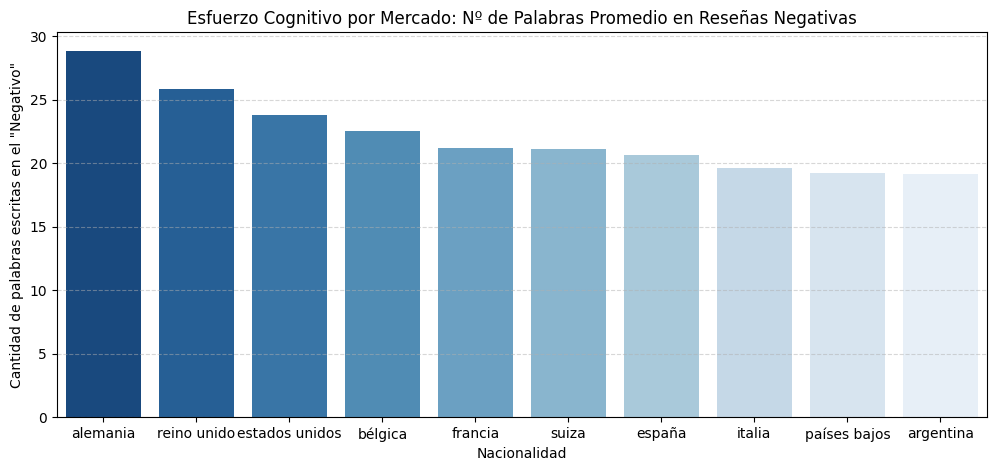

In [92]:
# Calculamos el conteo de palabras reales en la columna original de quejas (negativo)
df_proyecto['longitud_queja'] = df_proyecto['negativo'].apply(lambda x: len(str(x).split()) if pd.notna(x) and str(x).lower() not in ['nada', 'ninguna', ''] else 0)

# Filtramos filas donde realmente existió una queja (longitud > 0) para no desvirtuar la media
df_quejas_reales = df_proyecto[df_proyecto['longitud_queja'] > 0]

# Agrupamos por nacionalidad para extraer la métrica exacta de esfuerzo verbal
analisis_esfuerzo = df_quejas_reales.groupby('nacionalidad').agg(
    longitud_media_palabras=('longitud_queja', 'mean'),
    maxima_longitud_registrada=('longitud_queja', 'max')
).round(1).sort_values(by='longitud_media_palabras', ascending=False)

print("--- NÚMERO DE PALABRAS EN LA QUEJA ---")
display(analisis_esfuerzo)

# Gráfico de barras para la entrega/diapositivas
plt.figure(figsize=(12, 5))
sns.barplot(data=df_quejas_reales, x='nacionalidad', y='longitud_queja', errorbar=None, palette='Blues_r', order=analisis_esfuerzo.index)
plt.title('Esfuerzo Cognitivo por Mercado: Nº de Palabras Promedio en Reseñas Negativas')
plt.xlabel('Nacionalidad')
plt.ylabel('Cantidad de palabras escritas en el "Negativo"')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 2.4. Nota media según la habitación que se haya escogido.

In [ ]:
print("--- NOTA MEDIA SEGÚN EL TIPO DE VIAJERO ---")
analisis_viajero = df_proyecto.groupby('detalles_hab')['nota'].agg(['mean', 'count']).round(2)
display(analisis_viajero)

# Extraemos qué queja domina en cada tipo de cliente (ejemplo con España)
df_es = df_proyecto[df_proyecto['nacionalidad'] == 'españa']
for tipo in df_es['detalles_hab'].dropna().unique()[:3]:
    df_sub = df_es[df_es['detalles_hab'] == tipo]
    print(f"\nTop menciones de quejas para el segmento [{tipo}]:")
    print(df_sub['negativo_clean'].str.split(expand=True).stack().value_counts().head(3))

--- NOTA MEDIA SEGÚN EL TIPO DE VIAJERO ---


,mean,count
detalles_hab,,
2 habitaciones dobles deluxe comunicadas,9.05,86
alojamiento the level supreme,8.97,142
cama en habitación compartida mixta de 4 camas,8.32,398
cama en habitación compartida mixta de 6 camas,8.13,305
cama en habitación compartida mixta de 8 camas,8.33,273
...,...,...
suite junior con vistas al mar,8.21,90
suite junior supreme the level,9.06,62
suite presidencial the level,9.20,5



Top menciones de quejas para el segmento [2 habitaciones dobles deluxe comunicadas]:
piscina      3
funcionar    3
pequeño      2
Name: count, dtype: int64

Top menciones de quejas para el segmento [habitación doble estándar con vistas a la plaza del ayuntamiento]:
pequeño    10
haber       7
más         7
Name: count, dtype: int64

Top menciones de quejas para el segmento [habitación estándar]:
pequeño    36
baño       24
gustar     20
Name: count, dtype: int64


### 2.5. Análisis de calificaciones por bloque geográfico
Clasificamos las nacionalidades en dos grandes bloques geográficos según su distancia y proximidad cultural con el destino: el entorno europeo y el mercado intercontinental de larga distancia. A continuación, aplicamos esta segmentación al conjunto de datos para calcular la nota media de cada bloque, contrastando si el factor de la distancia física influye de manera directa en las expectativas y el nivel de exigencia numérica del turista.

In [ ]:
# Definimos los bloques geográficos basados en tus países
paises_proximidad = ['españa', 'francia', 'italia', 'reino unido', 'países bajos', 'alemania', 'suiza', 'bélgica']
paises_distancia = ['argentina', 'estados unidos']

# Creamos la nueva variable de segmentación cultural
def asignar_bloque(pais):
    if pais in paises_proximidad: return 'Europa (Proximidad)'
    if pais in paises_distancia: return 'Intercontinental (Larga Distancia)'
    return 'Otros'

df_proyecto['bloque_cultural'] = df_proyecto['nacionalidad'].apply(asignar_bloque)

# Comparamos las notas medias para ver el impacto reputacional
print("--- NOTA MEDIA POR BLOQUE GEOGRÁFICO ---")
print(df_proyecto.groupby('bloque_cultural')['nota'].mean().round(2))

# Extraemos el Top de quejas para ver si se rompe la homogeneidad
print("\n--- QUEJAS TOP: EUROPA ---")
df_euro = df_proyecto[df_proyecto['bloque_cultural'] == 'Europa (Proximidad)']
print(df_euro['negativo_clean'].value_counts().head(5))

print("\n--- QUEJAS TOP: INTERCONTINENTAL ---")
df_inter = df_proyecto[df_proyecto['bloque_cultural'] == 'Intercontinental (Larga Distancia)']
print(df_inter['negativo_clean'].value_counts().head(5))

--- NOTA MEDIA POR BLOQUE GEOGRÁFICO ---
bloque_cultural
Europa (Proximidad)                   8.42
Intercontinental (Larga Distancia)    8.81
Name: nota, dtype: float64

--- QUEJAS TOP: EUROPA ---
negativo_clean
                26853
gustar            162
perfecto          161
pequeño            83
baño pequeño       62
Name: count, dtype: int64

--- QUEJAS TOP: INTERCONTINENTAL ---
negativo_clean
            1630
perfecto      14
gustar        13
queja          9
pequeño        9
Name: count, dtype: int64


### 2.6. Tendencia a añadir quejas en la columna de comentarios positivos por nacionalidad

In [24]:
# Buscamos palabras típicamente negativas ('pero', 'malo', 'pequeño', 'viejo', 'ruido') dentro de la columna de POSITIVOS
palabras_criticas = ['pero', 'pequeno', 'pequeño', 'ruido', 'antiguo', 'viejo', 'caro', 'defecto']

df_proyecto['critica_infiltrada'] = df_proyecto['positivo_clean'].fillna("").apply(
    lambda x: 1 if any(p in str(x).lower() for p in palabras_criticas) else 0
)

print("--- PORCENTAJE DE CLIENTES QUE SE QUEJAN INCLUSO EN LA COLUMNA DE POSITIVOS ---")
critica_cultural = df_proyecto.groupby('nacionalidad')['critica_infiltrada'].mean() * 100
display(critica_cultural.sort_values(ascending=False).round(1))

--- PORCENTAJE DE CLIENTES QUE SE QUEJAN INCLUSO EN LA COLUMNA DE POSITIVOS ---


nacionalidad
alemania          6.0
reino unido       5.4
bélgica           4.8
países bajos      4.4
francia           4.1
estados unidos    3.8
suiza             3.6
italia            2.7
argentina         1.9
españa            1.8
Name: critica_infiltrada, dtype: float64

### 2.7. Análisis de especificidad
A continuación realizaremos un análosis de especifidad que aísla el ruido de las quejas masivas. Primero binarizamos el texto libre generando variables categóricas para los seis problemas más recurrentes y construimos. Aplicamos un test estadístico de Chi-cuadrado para modelar las frecuencias teóricas globales y calculamos la matriz de residuos estandarizados.

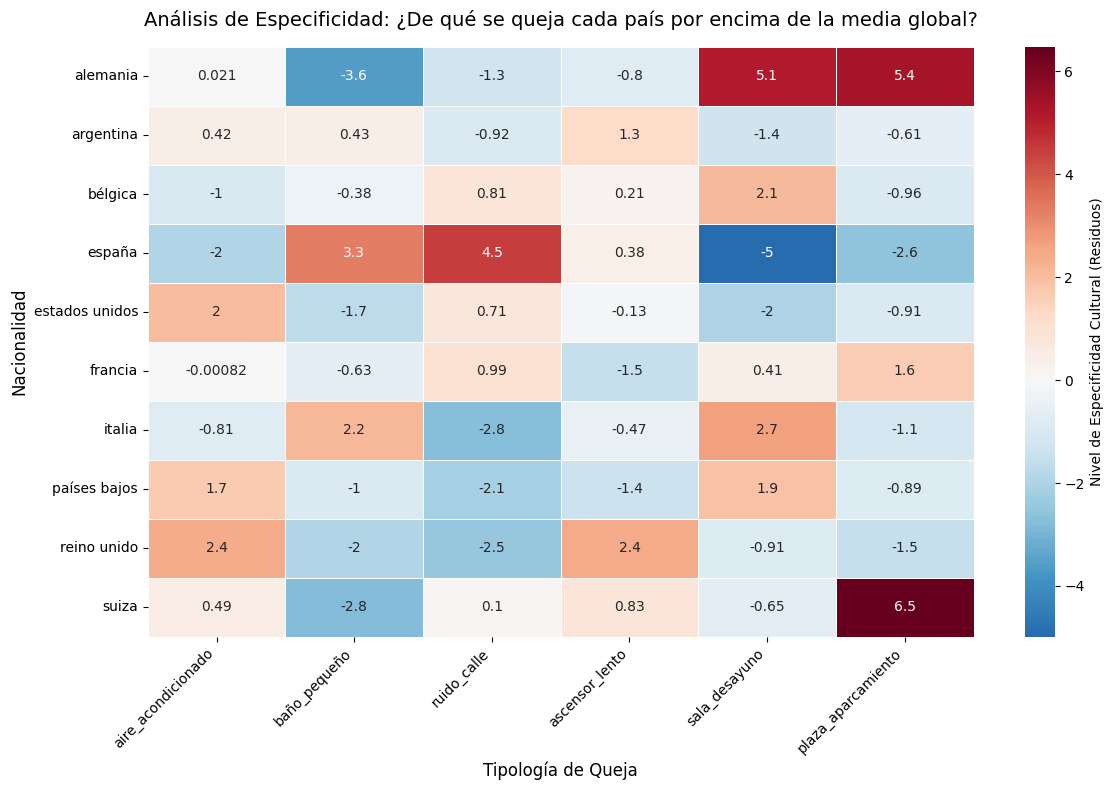

In [94]:
# Creamos las variables dummy de las quejas clave en el dataset general
df_proyecto['aire_acondicionado'] = df_proyecto['negativo_clean'].fillna("").str.contains('aire acondicionado').astype(int)
df_proyecto['baño_pequeño'] = df_proyecto['negativo_clean'].fillna("").str.contains('baño pequeño').astype(int)
df_proyecto['ruido_calle'] = df_proyecto['negativo_clean'].fillna("").str.contains('ruido calle').astype(int)
df_proyecto['ascensor_lento'] = df_proyecto['negativo_clean'].fillna("").str.contains('ascensor lento').astype(int)
df_proyecto['sala_desayuno'] = df_proyecto['negativo_clean'].fillna("").str.contains('sala desayuno').astype(int)
df_proyecto['plaza_aparcamiento'] = df_proyecto['negativo_clean'].fillna("").str.contains('plaza aparcamiento').astype(int)

# Creamos la tabla de contingencia (País vs Quejas) sumando las ocurrencias
lista_quejas = ['aire_acondicionado', 'baño_pequeño', 'ruido_calle', 'ascensor_lento', 'sala_desayuno', 'plaza_aparcamiento']
tabla_contingencia = df_proyecto.groupby('nacionalidad')[lista_quejas].sum()

# Aplicamos el test de Chi-cuadrado para obtener los residuos estandarizados
# Los residuos miden cuánto se aleja la realidad de la media teórica global
chi2, p, dof, esperados = chi2_contingency(tabla_contingencia)
residuos = (tabla_contingencia-esperados)/(esperados ** 0.5)

# Pintamos el mapa de calor de las desviaciones culturales
plt.figure(figsize=(12, 8))
sns.heatmap(
    residuos, 
    annot=True, 
    cmap='RdBu_r', 
    center=0, 
    cbar_kws={'label': 'Nivel de Especificidad Cultural (Residuos)'},
    linewidths=0.5
)

plt.title('Análisis de Especificidad: ¿De qué se queja cada país por encima de la media global?', fontsize=14, pad=15)
plt.xlabel('Tipología de Queja', fontsize=12)
plt.ylabel('Nacionalidad', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Referencias
- https://antonio-velazquez-bustamante.medium.com/comparing-political-speeches-with-python-and-nlp-54cd506e91b9  
- https://acua.qcri.org/blog/log-odds-ratio-going-beyond-simple-term-frequencies-to-characterize-textual-categories/  
- https://www.cambridge.org/core/journals/political-analysis/article/fightin-words-lexical-feature-selection-and-evaluation-for-identifying-the-content-of-political-conflict/81B3703230D21620B81EB6E2266C7A66